In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/wine-quality-dataset/WineQT.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.drop('Id', axis=1, inplace=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
print("Shape :", df.shape)

print("\nInformation")
print(df.info())

print("\nStatistics")
print(df.describe())

Shape : (1143, 12)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB
None

Statistics
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count 

In [6]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


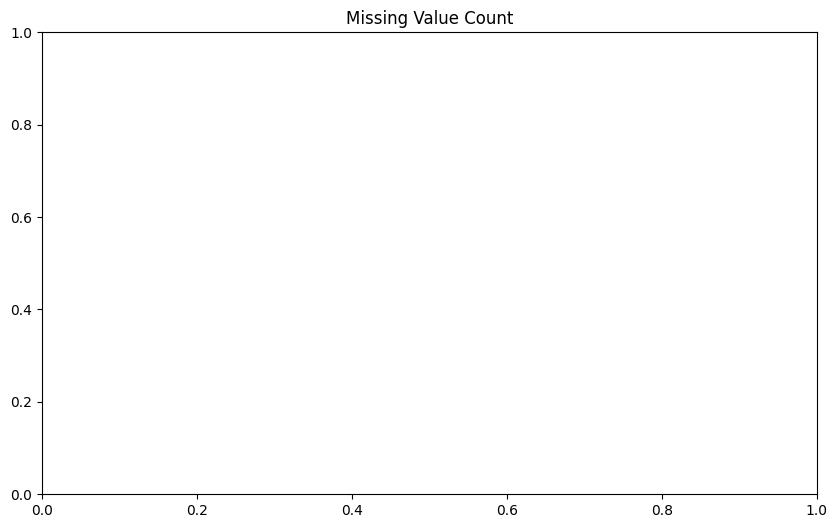

In [7]:
missing_count = df.isnull().sum()

missing_count = missing_count[
    missing_count > 0
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_count.values,
    y=missing_count.index
)

plt.title("Missing Value Count")

plt.show()

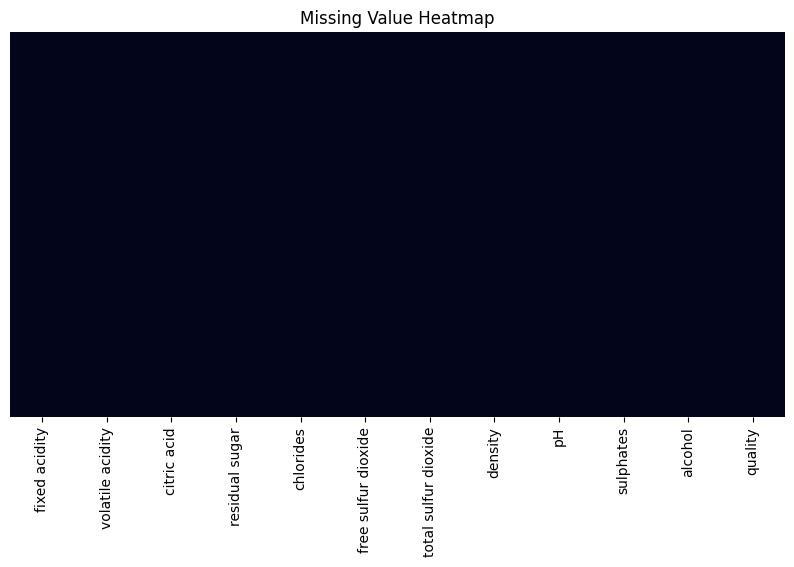

In [8]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title(
    "Missing Value Heatmap"
)

plt.show()

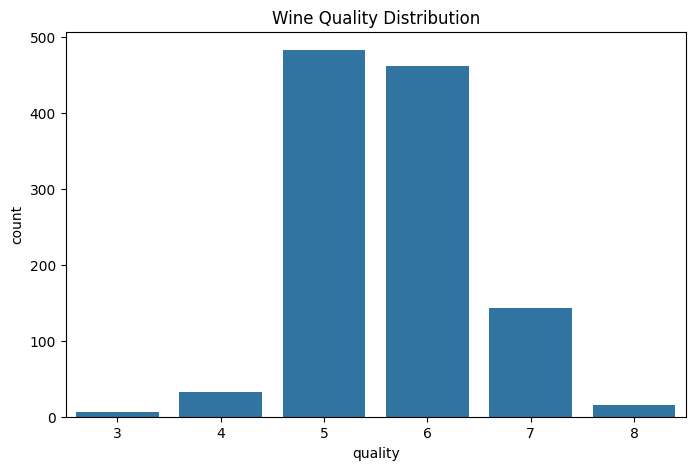

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=df
)

plt.title(
    "Wine Quality Distribution"
)

plt.show()

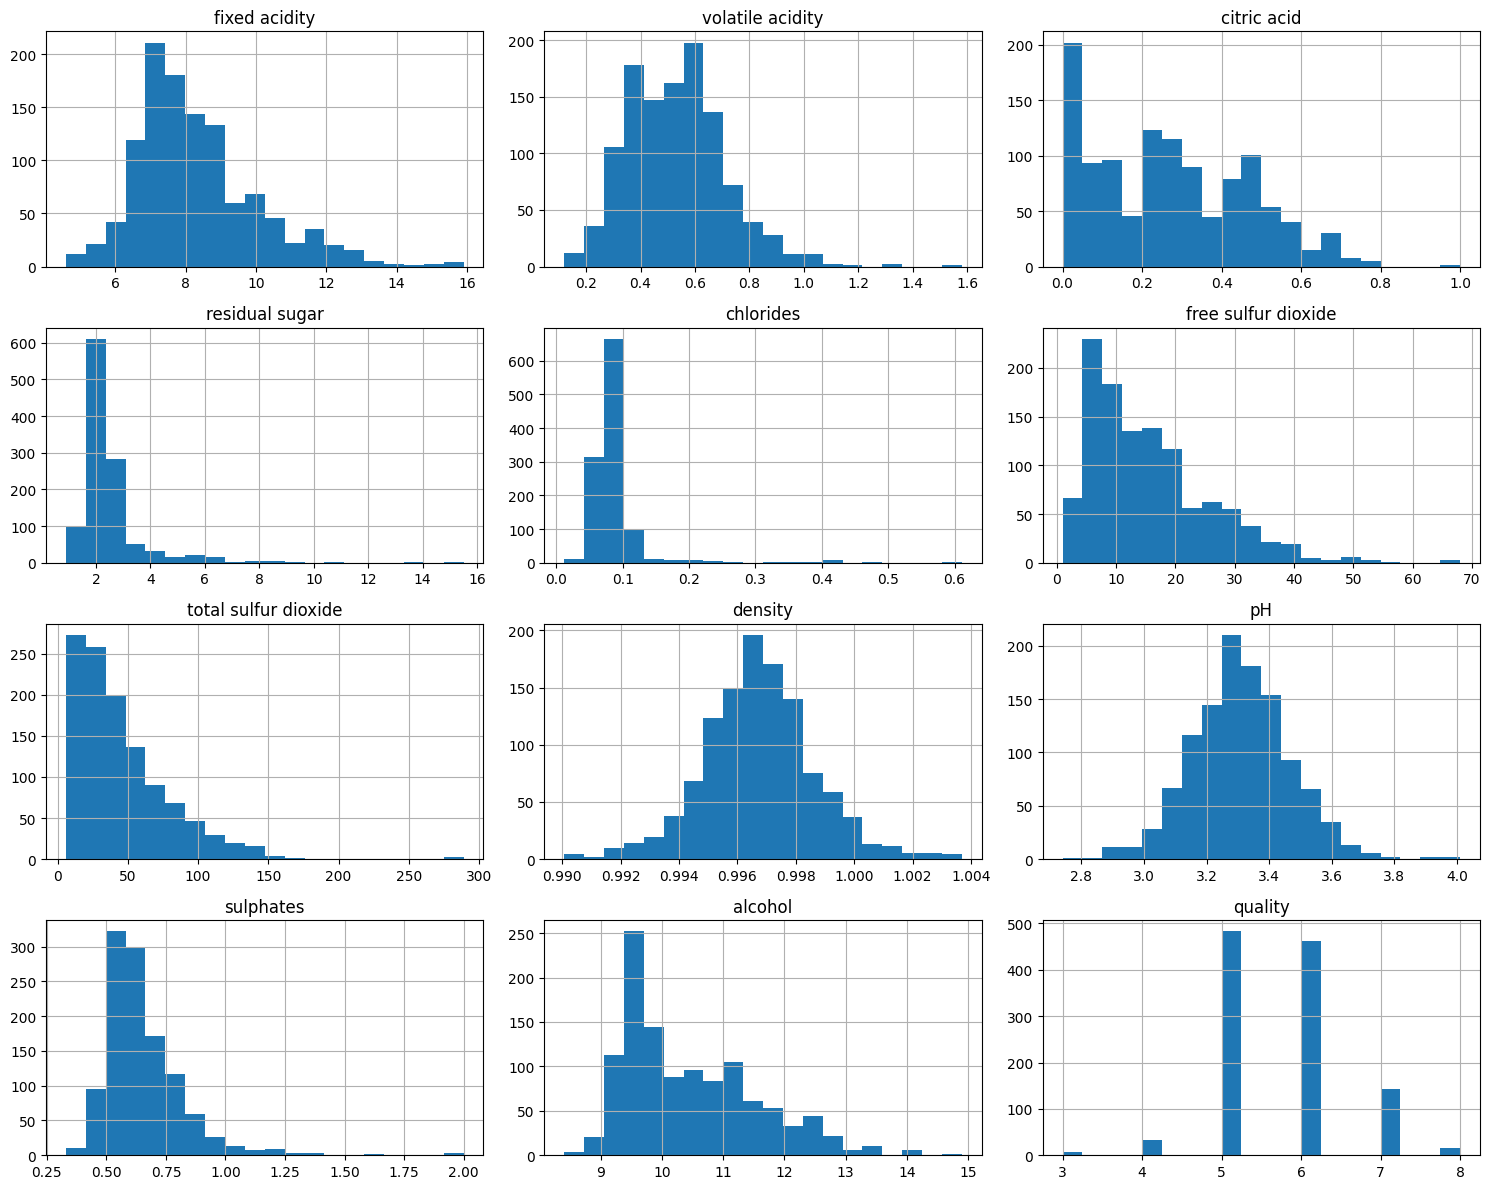

In [10]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

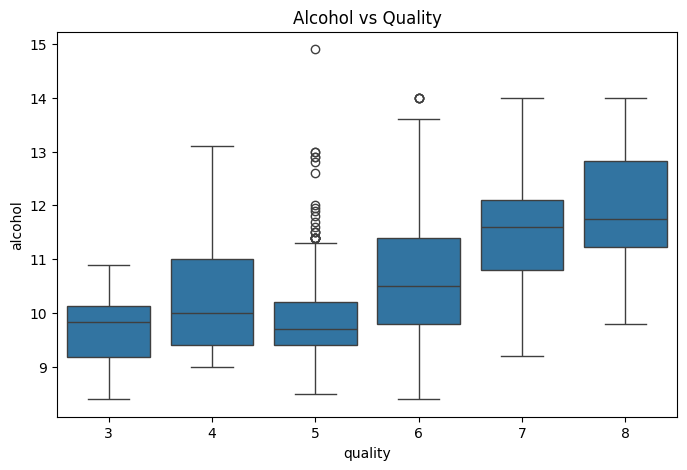

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='alcohol',
    data=df
)

plt.title(
    "Alcohol vs Quality"
)

plt.show()

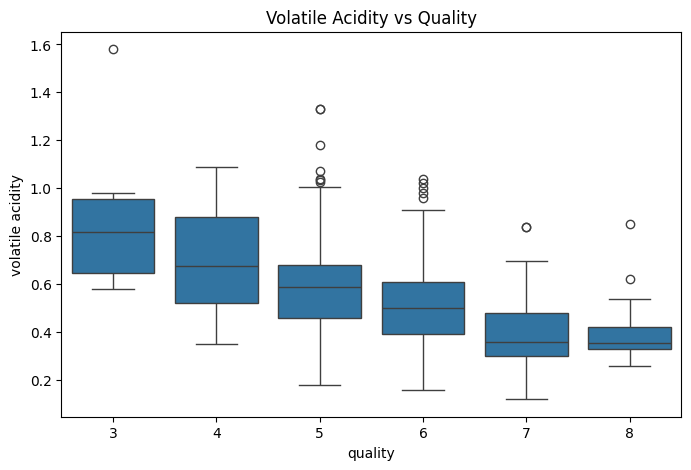

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='volatile acidity',
    data=df
)

plt.title(
    "Volatile Acidity vs Quality"
)

plt.show()

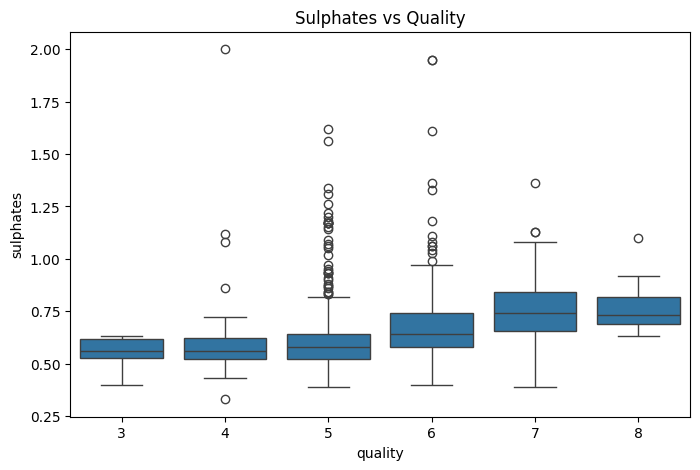

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='sulphates',
    data=df
)

plt.title(
    "Sulphates vs Quality"
)

plt.show()

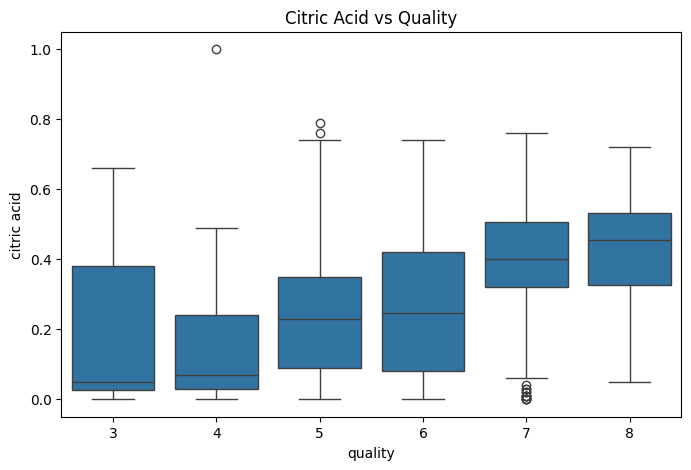

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='citric acid',
    data=df
)

plt.title(
    "Citric Acid vs Quality"
)

plt.show()

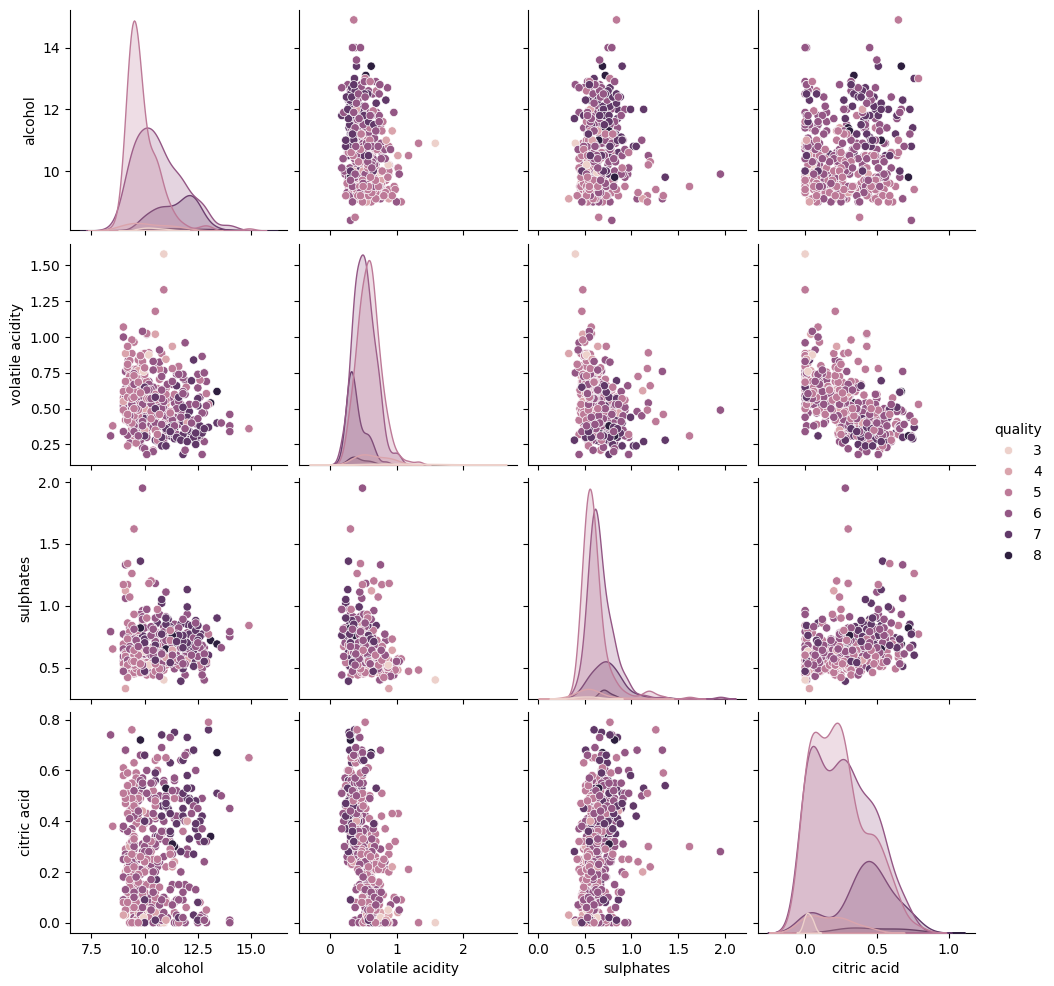

In [15]:
sample_df = df.sample(
    500,
    random_state=42
)

sns.pairplot(
    sample_df[
        [
            'alcohol',
            'volatile acidity',
            'sulphates',
            'citric acid',
            'quality'
        ]
    ],
    hue='quality'
)

plt.show()

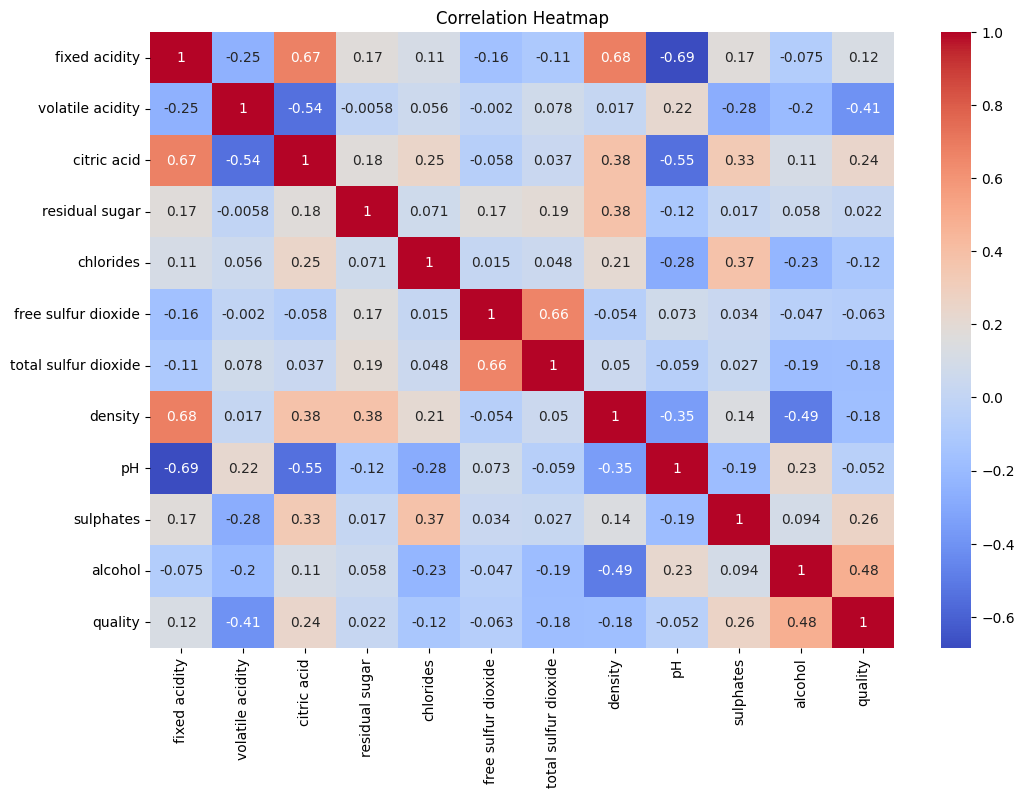

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [17]:
X = df.drop(
    'quality',
    axis=1
)

y = df['quality']

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X,y)

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
10,alcohol,0.149469
9,sulphates,0.120018
1,volatile acidity,0.104747
6,total sulfur dioxide,0.098143
7,density,0.087986
4,chlorides,0.077026
8,pH,0.076770
2,citric acid,0.074741
0,fixed acidity,0.073636
5,free sulfur dioxide,0.069901


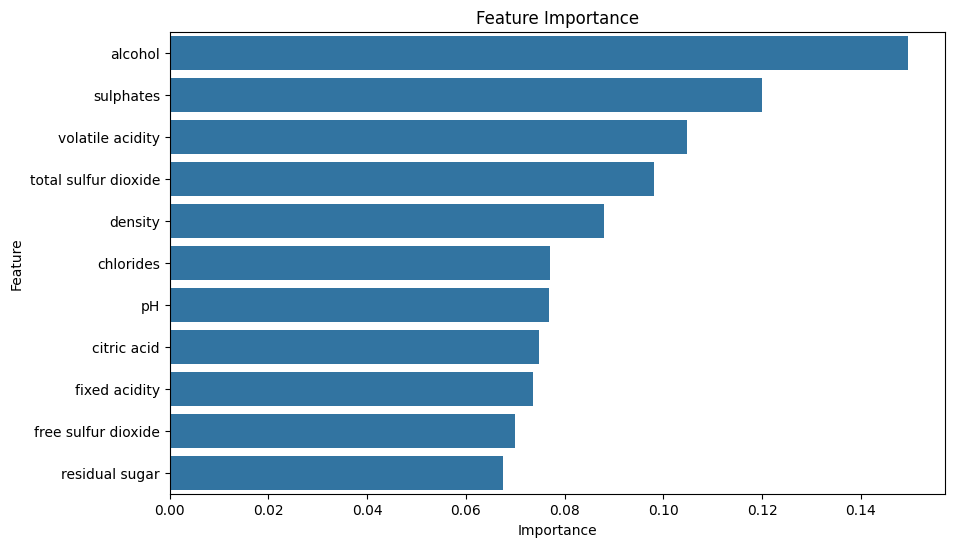

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

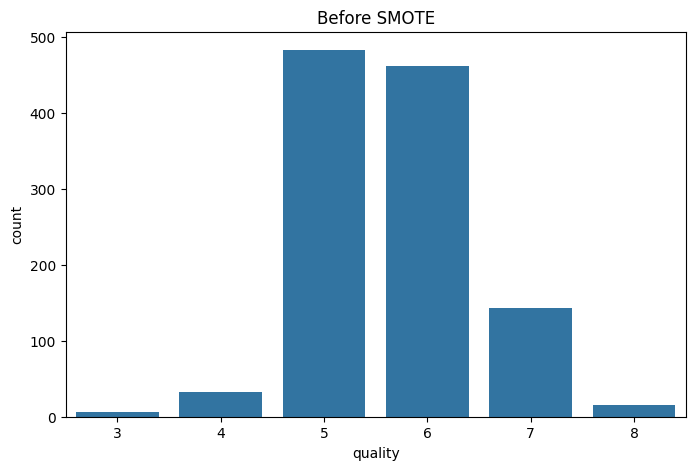

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y
)

plt.title(
    "Before SMOTE"
)

plt.show()

In [20]:
smote = SMOTE(
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(
    X,
    y
)

print(
    y_resampled.value_counts()
)

quality
5    483
6    483
7    483
4    483
8    483
3    483
Name: count, dtype: int64


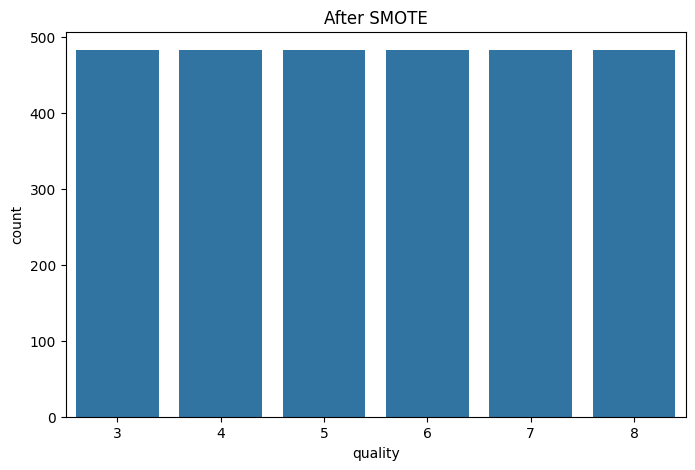

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y_resampled
)

plt.title(
    "After SMOTE"
)

plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(

    X_resampled,
    y_resampled,

    test_size=0.20,

    random_state=42,

    stratify=y_resampled
)

In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [36]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "Naive Bayes":
        GaussianNB()
}

In [37]:
results = []

best_model = None
best_accuracy = 0
best_name = ""

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    pre = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([
        name,
        acc,
        pre,
        rec,
        f1
    ])

    print("\n", "="*50)
    print(name)
    print("="*50)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

        best_name = name


Logistic Regression
              precision    recall  f1-score   support

           3       0.89      0.94      0.91        96
           4       0.53      0.54      0.54        96
           5       0.61      0.60      0.60        97
           6       0.46      0.34      0.39        97
           7       0.51      0.51      0.51        97
           8       0.67      0.80      0.73        97

    accuracy                           0.62       580
   macro avg       0.61      0.62      0.61       580
weighted avg       0.61      0.62      0.61       580


KNN
              precision    recall  f1-score   support

           3       0.94      1.00      0.97        96
           4       0.78      0.99      0.87        96
           5       0.61      0.49      0.55        97
           6       0.50      0.30      0.37        97
           7       0.76      0.78      0.77        97
           8       0.82      1.00      0.90        97

    accuracy                           0.76       5

In [38]:
results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.843103,0.836110,0.843103,0.838375
1,KNN,0.760345,0.733329,0.760345,0.737809
3,Decision Tree,0.756897,0.752256,0.756897,0.754288
2,SVM,0.750000,0.737694,0.750000,0.741191
0,Logistic Regression,0.620690,0.610051,0.620690,0.612717
5,Naive Bayes,0.496552,0.473991,0.496552,0.468198


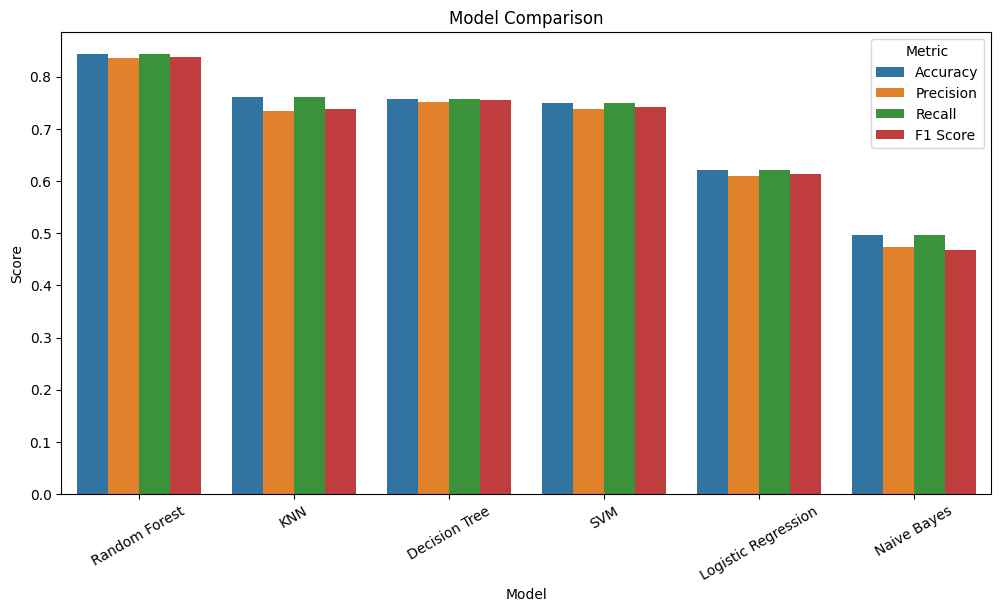

In [39]:
results_melted = results_df.melt(

    id_vars='Model',

    var_name='Metric',

    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.xticks(rotation=30)

plt.title(
    "Model Comparison"
)

plt.show()

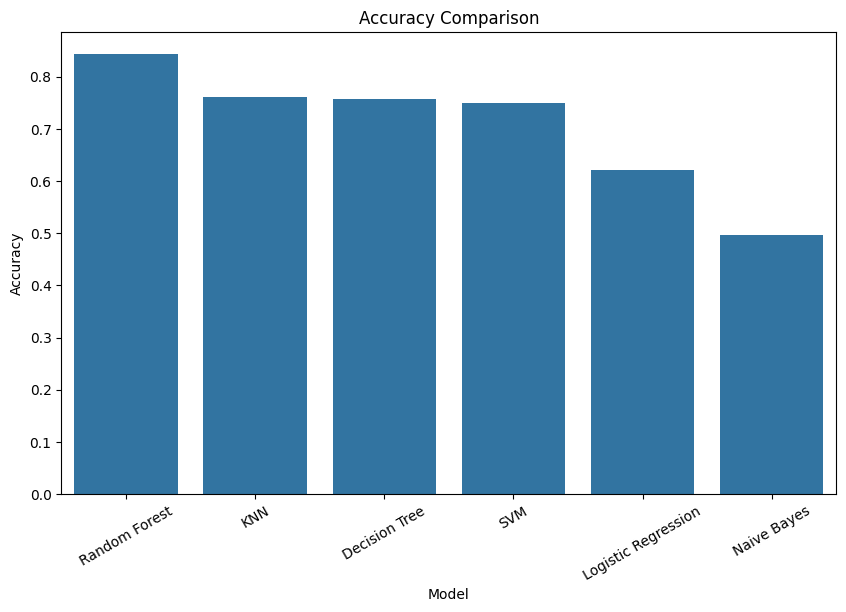

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.xticks(rotation=30)

plt.title(
    "Accuracy Comparison"
)

plt.show()

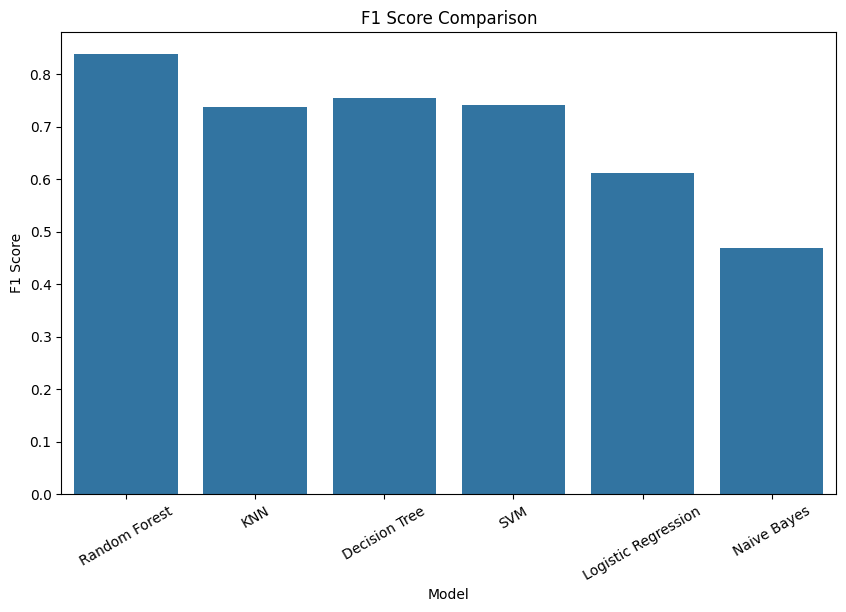

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1 Score'
)

plt.xticks(rotation=30)

plt.title(
    "F1 Score Comparison"
)

plt.show()

In [42]:
print(
    "Best Model :",
    best_name
)

print(
    "Best Accuracy :",
    round(best_accuracy*100,2),
    "%"
)

Best Model : Random Forest
Best Accuracy : 84.31 %


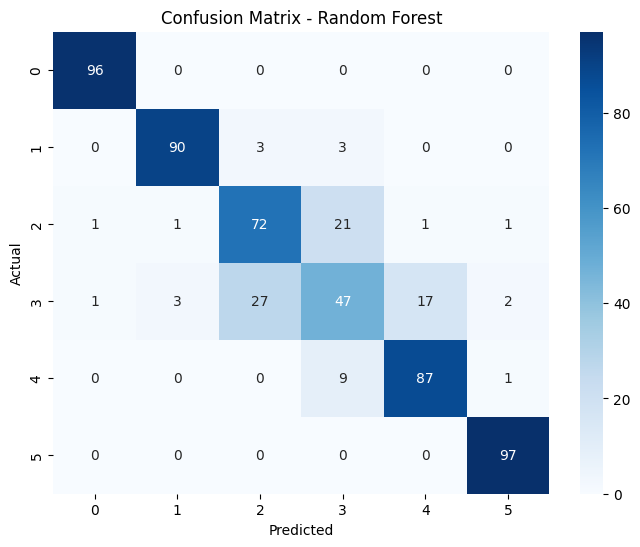

In [43]:
y_pred_best = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_name}'
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()